In [1]:
"""
Minas Gerais frost-signal long strategy on KC (Arabica) front-month futures.

Signal : NASA POWER T2M_MIN at (-21.55, -45.43) < 4.5 C
Trade  : go long at the NEXT session's close, hold 10 trading days, flat otherwise.
         New signals while already in a position are ignored (non-overlapping).
"""

import numpy as np
import pandas as pd

WX_PATH = "Brazil Minas Gerais 1990-2026.csv"
PX_PATH = "KCc1 daily arabica 1990-2026.csv"

TEMP_THRESHOLD = 4.5     # degrees C on daily minimum
HOLD_DAYS = 10           # trading days
COST_BPS = 5             # round-trip cost in basis points per side
TRADING_DAYS = 252


# load data
def load_weather(path=WX_PATH):
    df = pd.read_csv(path, skiprows=15)                     # skip NASA POWER header block
    df["date"] = pd.to_datetime(
        df["YEAR"].astype(str) + "-" + df["DOY"].astype(str), format="%Y-%j"
    )
    df = df.replace(-999, np.nan)                           # POWER missing-data sentinel
    return df[["date", "T2M", "T2M_MIN", "T2M_MAX"]].dropna(subset=["T2M_MIN"])


def load_prices(path=PX_PATH):
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["Exchange Date"], format="%d-%b-%Y")
    df = df[["date", "Close"]].sort_values("date").drop_duplicates("date")
    return df.reset_index(drop=True)


# signal
def build_panel(px, wx):
    
    px = px.sort_values("date").reset_index(drop=True)
    wx = wx.sort_values("date").reset_index(drop=True)
    # label every weather day with the first trading session at or after it
    idx = np.searchsorted(px["date"].values, wx["date"].values, side="left")
    wx = wx.assign(sess_idx=idx)
    wx = wx[wx["sess_idx"] < len(px)]
    agg = wx.groupby("sess_idx").agg(
        T2M_MIN=("T2M_MIN", "min"), T2M=("T2M", "mean"), T2M_MAX=("T2M_MAX", "max")
    )
    df = px.join(agg, how="left")
    df["frost"] = df["T2M_MIN"] < TEMP_THRESHOLD
    # a frost that already triggered on the previous session is not a new event
    df["signal"] = df["frost"] & ~df["frost"].shift(1, fill_value=False)
    return df


def build_positions(df, hold=HOLD_DAYS):
    """Position is 1 on days we hold the future. Entry is the close AFTER the
    signal day, so no look-ahead: the day's min temp is only known once the day ends."""
    pos = np.zeros(len(df))
    trades = []
    i = 0
    while i < len(df):
        if df["signal"].iat[i]:
            entry = i + 1                                   # execute next close
            exit_ = min(entry + hold, len(df) - 1)
            if entry >= len(df) - 1:
                break
            pos[entry + 1 : exit_ + 1] = 1                  # returns accrue after entry
            trades.append(
                {
                    "signal_date": df["date"].iat[i],
                    "t2m_min": df["T2M_MIN"].iat[i],
                    "entry_date": df["date"].iat[entry],
                    "entry_px": df["Close"].iat[entry],
                    "exit_date": df["date"].iat[exit_],
                    "exit_px": df["Close"].iat[exit_],
                }
            )
            i = exit_ + 1                                   # no overlapping trades
        else:
            i += 1
    df["position"] = pos
    tr = pd.DataFrame(trades)
    if not tr.empty:
        tr["gross_ret"] = tr["exit_px"] / tr["entry_px"] - 1
        tr["net_ret"] = tr["gross_ret"] - 2 * COST_BPS / 1e4
        tr["days_held"] = (tr["exit_date"] - tr["entry_date"]).dt.days
    return df, tr


# metrics
def run_backtest(df):
    df = df.copy()
    df["mkt_ret"] = df["Close"].pct_change().fillna(0)
    df["strat_ret"] = df["position"] * df["mkt_ret"]
    # charge cost on each change in position
    turns = df["position"].diff().abs().fillna(df["position"])
    df["strat_ret"] -= turns * COST_BPS / 1e4
    df["equity"] = (1 + df["strat_ret"]).cumprod()
    df["bh_equity"] = (1 + df["mkt_ret"]).cumprod()
    return df


def metrics(ret, equity, label):
    yrs = len(ret) / TRADING_DAYS
    total = equity.iloc[-1] - 1
    cagr = equity.iloc[-1] ** (1 / yrs) - 1
    vol = ret.std() * np.sqrt(TRADING_DAYS)
    sharpe = ret.mean() / ret.std() * np.sqrt(TRADING_DAYS) if ret.std() > 0 else np.nan
    downside = ret[ret < 0].std()
    sortino = ret.mean() / downside * np.sqrt(TRADING_DAYS) if downside > 0 else np.nan
    dd = equity / equity.cummax() - 1
    maxdd = dd.min()
    return {
        "strategy": label,
        "total_return": total,
        "CAGR": cagr,
        "ann_vol": vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": maxdd,
        "calmar": cagr / abs(maxdd) if maxdd else np.nan,
        "time_in_market": np.nan,
    }


def main():
    px, wx = load_prices(), load_weather()
    df = build_panel(px, wx)
    df, trades = build_positions(df)
    df = run_backtest(df)

    m_strat = metrics(df["strat_ret"], df["equity"], "Frost long-10d")
    m_strat["time_in_market"] = df["position"].mean()
    m_bh = metrics(df["mkt_ret"], df["bh_equity"], "Buy & hold KC")
    m_bh["time_in_market"] = 1.0

    # in-trade-only Sharpe
    active = df.loc[df["position"] == 1, "strat_ret"]
    active_sharpe = active.mean() / active.std() * np.sqrt(TRADING_DAYS)

    summary = pd.DataFrame([m_strat, m_bh]).set_index("strategy")
    print("\n=== HEADLINE METRICS ===")
    print(summary.to_string(float_format=lambda x: f"{x: .3f}"))
    print(f"\nSharpe while in position only: {active_sharpe: .3f}")

    print("\n=== TRADE LOG ===")
    cols = ["signal_date", "t2m_min", "entry_date", "entry_px", "exit_px", "net_ret"]
    print(
        trades[cols].to_string(
            index=False, formatters={"net_ret": lambda x: f"{x: .2%}"}
        )
    )

    wins = (trades["net_ret"] > 0).sum()
    print("\n=== TRADE STATS ===")
    print(f"trades            : {len(trades)}")
    print(f"hit rate          : {wins/len(trades):.1%}")
    print(f"mean trade        : {trades['net_ret'].mean():.2%}")
    print(f"median trade      : {trades['net_ret'].median():.2%}")
    print(f"best / worst      : {trades['net_ret'].max():.2%} / {trades['net_ret'].min():.2%}")
    print(f"avg win / avg loss: {trades.loc[trades.net_ret>0,'net_ret'].mean():.2%} / "
          f"{trades.loc[trades.net_ret<=0,'net_ret'].mean():.2%}")
    t = trades["net_ret"]
    print(f"t-stat vs zero    : {t.mean()/(t.std()/np.sqrt(len(t))):.2f}")

    df.to_csv("backtest_daily.csv", index=False)
    trades.to_csv("trade_log.csv", index=False)
    return df, trades


if __name__ == "__main__":
    main()


=== HEADLINE METRICS ===
                total_return   CAGR  ann_vol  sharpe  sortino  max_drawdown  calmar  time_in_market
strategy                                                                                           
Frost long-10d        -0.025 -0.001    0.072   0.025    0.004        -0.344  -0.002           0.012
Buy & hold KC          3.235  0.040    0.380   0.293    0.460        -0.870   0.046           1.000

Sharpe while in position only:  0.246

=== TRADE LOG ===
signal_date  t2m_min entry_date  entry_px  exit_px net_ret
 1990-05-21     2.91 1990-05-22      0.97     0.94  -3.19%
 1994-06-27     0.48 1994-06-28      1.70     2.45  44.02%
 1997-06-09     2.50 1997-06-10      2.18     1.98  -9.27%
 2000-07-17     2.41 2000-07-18      1.17     0.86 -26.60%
 2011-08-05     3.50 2011-08-08      2.34     2.65  13.15%
 2019-07-08     3.98 2019-07-09      1.06     1.02  -3.87%
 2020-05-27     4.37 2020-05-28      0.99     0.96  -3.13%
 2021-07-01     4.10 2021-07-02      1.53   

/var/folders/zz/f4d8ydn15kqfjy20b3p_dqy80000gn/T/ipykernel_83700/1966369843.py:97: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["mkt_ret"] = df["Close"].pct_change().fillna(0)


/var/folders/zz/f4d8ydn15kqfjy20b3p_dqy80000gn/T/ipykernel_83700/1966369843.py:97: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["mkt_ret"] = df["Close"].pct_change().fillna(0)



=== SUMMARY ===
Total return            -2.50%
CAGR                    -0.07%
Annualised vol           7.22%
Sharpe                   0.025
Max drawdown           -34.42%
Time in market           1.20%
Trades                      11
Hit rate                   36%
Mean trade              +1.02%
Median trade            -3.13%
Best / worst      +44.0% / -26.6%
figure saved -> frost_strategy_equity.pdf


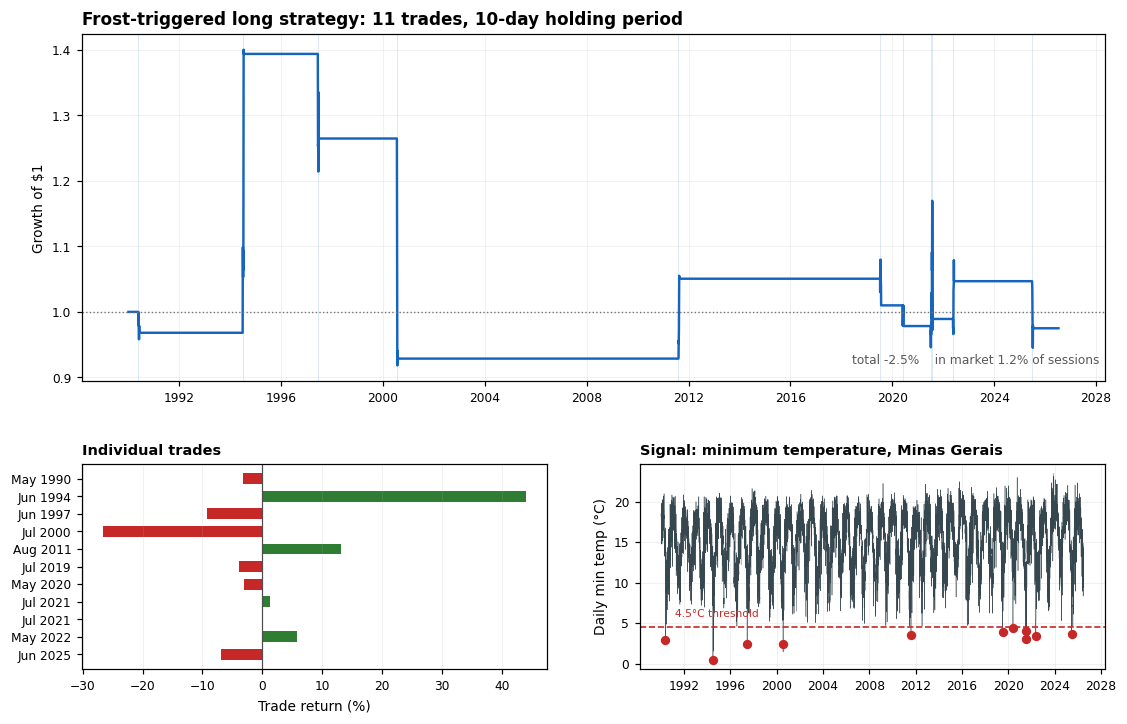

In [2]:

# EQUITY CURVE AND DIAGNOSTICS


import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "pdf.fonttype": 42,           # embed TrueType so the PDF text stays selectable
    "font.family": "DejaVu Sans",
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "figure.dpi": 110,
})


def summary_stats(df, trades):
    """Headline numbers, printed alongside the figure."""
    eq = df["equity"]
    dd = eq / eq.cummax() - 1
    r = df["strat_ret"]
    yrs = len(r) / TRADING_DAYS
    t = trades["net_ret"]
    return {
        "Total return":     f"{eq.iloc[-1] - 1:+.2%}",
        "CAGR":             f"{eq.iloc[-1] ** (1/yrs) - 1:+.2%}",
        "Annualised vol":   f"{r.std() * np.sqrt(TRADING_DAYS):.2%}",
        "Sharpe":           f"{r.mean() / r.std() * np.sqrt(TRADING_DAYS):.3f}",
        "Max drawdown":     f"{dd.min():.2%}",
        "Time in market":   f"{df['position'].mean():.2%}",
        "Trades":           f"{len(trades)}",
        "Hit rate":         f"{(t > 0).mean():.0%}",
        "Mean trade":       f"{t.mean():+.2%}",
        "Median trade":     f"{t.median():+.2%}",
        "Best / worst":     f"{t.max():+.1%} / {t.min():+.1%}",
    }


def plot_results(df, trades, save_as="frost_strategy_equity.pdf"):
    fig = plt.figure(figsize=(12, 7.5))
    gs = fig.add_gridspec(2, 2, height_ratios=[2.2, 1.3], hspace=0.30, wspace=0.20)

    # 1. equity curve, with each holding period shaded
    ax = fig.add_subplot(gs[0, :])
    ax.plot(df["date"], df["equity"], color="#1565c0", lw=1.6, rasterized=True)
    ax.axhline(1.0, color="0.45", ls=":", lw=0.9)
    for _, t in trades.iterrows():
        ax.axvspan(t["entry_date"], t["exit_date"], color="#1565c0",
                   alpha=0.14, lw=0)
    ax.set_ylabel("Growth of $1", fontsize=9)
    ax.grid(alpha=0.22)
    ax.tick_params(labelsize=8)
    ax.set_title(f"Frost-triggered long strategy: {len(trades)} trades, "
                 f"{HOLD_DAYS}-day holding period",
                 fontsize=11, fontweight="bold", loc="left")
    ax.text(0.995, 0.05,
            f"total {df['equity'].iloc[-1]-1:+.1%}    "
            f"in market {df['position'].mean():.1%} of sessions",
            transform=ax.transAxes, ha="right", fontsize=8, color="0.35")
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # 2. individual trade returns
    ax2 = fig.add_subplot(gs[1, 0])
    cols = ["#2e7d32" if x > 0 else "#c62828" for x in trades["net_ret"]]
    ax2.barh(range(len(trades)), trades["net_ret"] * 100, color=cols, height=0.62)
    ax2.set_yticks(range(len(trades)))
    ax2.set_yticklabels([f"{t:%b %Y}" for t in trades["signal_date"]], fontsize=7.5)
    ax2.invert_yaxis()
    ax2.axvline(0, color="0.3", lw=0.8)
    ax2.set_xlabel("Trade return (%)", fontsize=9)
    ax2.grid(alpha=0.22, axis="x")
    ax2.tick_params(labelsize=8)
    ax2.set_title("Individual trades", fontsize=9.5, fontweight="bold", loc="left")

    #3. the signal itself
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(df["date"], df["T2M_MIN"], lw=0.3, color="#37474f", rasterized=True)
    ax3.axhline(TEMP_THRESHOLD, color="#c62828", ls="--", lw=1.1)
    ax3.scatter(trades["signal_date"], trades["t2m_min"], s=26,
                color="#c62828", zorder=5)
    ax3.set_ylabel("Daily min temp (\u00b0C)", fontsize=9)
    ax3.text(df["date"].iloc[300], TEMP_THRESHOLD + 1.3,
             f"{TEMP_THRESHOLD}\u00b0C threshold", fontsize=7, color="#c62828")
    ax3.grid(alpha=0.22)
    ax3.tick_params(labelsize=8)
    ax3.set_title("Signal: minimum temperature, Minas Gerais",
                  fontsize=9.5, fontweight="bold", loc="left")

    fig.savefig(save_as, bbox_inches="tight", pad_inches=0.25, dpi=300)
    print(f"figure saved -> {save_as}")
    return fig


#run it
px, wx = load_prices(), load_weather()
df = build_panel(px, wx)
df, trades = build_positions(df)
df = run_backtest(df)

print("\n=== SUMMARY ===")
for k, v in summary_stats(df, trades).items():
    print(f"{k:<18}{v:>12}")

fig = plot_results(df, trades)
plt.show()

In [6]:
"""
CHAPTER STRATEGY: THE FROST-TRIGGERED LONG POSITION IN ARABICA COFFEE
====================================================================
Signal : Minas Gerais daily minimum temperature (NASA POWER, MERRA-2)
         falls below 4.5 C -- a proxy for damaging radiative frost
Trade  : LONG KC front-month at the NEXT session's close
Exit   : after 60 trading days (approx. three calendar months)
Costs  : 5 bps per side. Overlapping signals ignored while a position is open.

"""
import numpy as np, pandas as pd

WX_PATH="Brazil Minas Gerais 1990-2026.csv"
PX_PATH="KCc1 daily arabica 1990-2026.csv"
THRESHOLD, HOLD, COST, TD = 4.5, 60, 0.0005, 252


def load():
    wx = pd.read_csv(WX_PATH, skiprows=15).replace(-999, np.nan)
    wx["date"]=pd.to_datetime(wx.YEAR.astype(str)+"-"+wx.DOY.astype(str),format="%Y-%j")
    wx = wx.dropna(subset=["T2M_MIN"])
    px = pd.read_csv(PX_PATH)
    px["date"]=pd.to_datetime(px["Exchange Date"],format="%d-%b-%Y")
    px=(px[["date","Close"]].sort_values("date").drop_duplicates("date")
          .dropna(subset=["Close"]).reset_index(drop=True))
    px["ret"]=px.Close.pct_change()
    s=np.searchsorted(px.date.values, wx.date.values, side="left")
    wx=wx.assign(s=s); wx=wx[wx.s<len(px)]
    return px.join(wx.groupby("s").agg(tmin=("T2M_MIN","min")))


def backtest(d, threshold=THRESHOLD, hold=HOLD):
    frost=d.tmin<threshold
    sig=(frost & ~frost.shift(1, fill_value=False)).values
    pos=np.zeros(len(d)); trades=[]; i=0
    while i < len(d)-2:
        if sig[i]:
            e=i+1; x=min(e+hold, len(d)-1)
            pos[e+1:x+1]=1
            trades.append(dict(signal_date=d.date.iat[i], tmin=d.tmin.iat[i],
                entry_date=d.date.iat[e], entry=d.Close.iat[e],
                exit_date=d.date.iat[x], exit=d.Close.iat[x],
                ret=d.Close.iat[x]/d.Close.iat[e]-1-2*COST))
            i=x+1
        else: i+=1
    pos=pd.Series(pos,index=d.index)
    r=(pos.shift(1).fillna(0)*d.ret).fillna(0)-pos.diff().abs().fillna(0)*COST
    return pos, r, (1+r).cumprod(), pd.DataFrame(trades)


def metrics(r, eq, label, exposure=1.0):
    dd=(eq/eq.cummax()-1).min(); ann=eq.iloc[-1]**(TD/len(r))-1
    dn=r[r<0].std()
    return dict(strategy=label, total=eq.iloc[-1]-1, CAGR=ann,
        vol=r.std()*np.sqrt(TD), sharpe=r.mean()/r.std()*np.sqrt(TD),
        sortino=r.mean()/dn*np.sqrt(TD), maxDD=dd, calmar=ann/abs(dd),
        exposure=exposure)


def main():
    d=load(); pos,r,eq,tr=backtest(d)
    bh=(1+d.ret.fillna(0)).cumprod()
    print("=== HEADLINE METRICS ===")
    print(pd.DataFrame([metrics(r,eq,"Frost long 60d",(pos!=0).mean()),
                        metrics(d.ret.fillna(0),bh,"Buy & hold KC")]
          ).set_index("strategy").to_string(float_format=lambda x:f"{x: .3f}"))

    print("\n=== TRADE LOG ===")
    print(tr.to_string(index=False,float_format=lambda x:f"{x:.2f}",
          formatters={"ret":lambda x:f"{x:+.1%}","tmin":lambda x:f"{x:.1f}"}))
    t=tr.ret
    print(f"\ntrades {len(t)} | hit {(t>0).mean():.0%} | mean {t.mean():+.2%} "
          f"| median {t.median():+.2%} | skew {t.skew():.2f} "
          f"| t-stat {t.mean()/(t.std()/np.sqrt(len(t))):.2f}")
    print(f"avg win {t[t>0].mean():+.1%} | avg loss {t[t<=0].mean():+.1%} "
          f"| win/loss ratio {abs(t[t>0].mean()/t[t<=0].mean()):.2f}")

    print("\n=== ROBUSTNESS: total return across the parameter grid ===")
    g=pd.DataFrame([[backtest(d,th,h)[2].iloc[-1]-1 for h in (20,40,60,90)]
                    for th in (3.5,4.5,5.5,6.5)],
                   index=[f"{th} C" for th in (3.5,4.5,5.5,6.5)],
                   columns=[f"{h}d" for h in (20,40,60,90)])
    print(g.to_string(float_format=lambda x:f"{x:+.1%}"))

    print("\n=== SUB-PERIOD STABILITY ===")
    for lab,m in [("1990-2001",d.date<"2002-01-01"),
                  ("2002-2013",(d.date>="2002-01-01")&(d.date<"2014-01-01")),
                  ("2014-2026",d.date>="2014-01-01")]:
        rr=r[m]; e=(1+rr).cumprod()
        print(f"  {lab}: total {e.iloc[-1]-1:+7.1%}  sharpe {rr.mean()/rr.std()*np.sqrt(TD):5.2f}")

    tr.to_csv("frost_long_trades.csv",index=False)
    pd.DataFrame({"date":d.date,"Close":d.Close,"tmin":d.tmin,"pos":pos,
                  "ret":r,"equity":eq,"bh":bh}).to_csv(
                  "frost_long_daily.csv",index=False)
    return d,pos,r,eq,bh,tr

if __name__=="__main__": main()

=== HEADLINE METRICS ===
                total   CAGR    vol  sharpe  sortino  maxDD  calmar  exposure
strategy                                                                     
Frost long 60d  0.495  0.011  0.117   0.152    0.055 -0.431   0.026     0.066
Buy & hold KC   3.235  0.041  0.380   0.294    0.461 -0.870   0.047     1.000

=== TRADE LOG ===
signal_date tmin entry_date  entry  exit_date  exit    ret
 1990-05-21  2.9 1990-05-22   0.97 1990-08-16  0.94  -3.2%
 1994-06-27  0.5 1994-06-28   1.70 1994-09-22  2.28 +34.0%
 1997-06-09  2.5 1997-06-10   2.18 1997-09-04  2.10  -3.8%
 2000-07-17  2.4 2000-07-18   1.17 2000-10-11  0.83 -29.2%
 2011-08-05  3.5 2011-08-08   2.34 2011-11-01  2.24  -4.4%
 2019-07-08  4.0 2019-07-09   1.06 2019-10-02  1.01  -4.8%
 2020-05-27  4.4 2020-05-28   0.99 2020-08-21  1.20 +21.1%
 2021-07-01  4.1 2021-07-02   1.53 2021-09-28  1.99 +30.0%
 2022-05-18  3.5 2022-05-19   2.19 2022-08-16  2.19  -0.1%
 2025-06-25  3.7 2025-06-26   3.10 2025-09-22  3.67 +1

In [7]:

# EQUITY CURVE AND DIAGNOSTICS -- 60-day frost strategy


import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "pdf.fonttype": 42,          # embed TrueType so PDF text stays selectable
    "font.family": "DejaVu Sans",
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "figure.dpi": 110,
})


def summary_stats(pos, r, eq, tr):
    """Headline numbers, printed alongside the figure."""
    dd = (eq / eq.cummax() - 1).min()
    t = tr["ret"]
    return {
        "Total return":     f"{eq.iloc[-1] - 1:+.2%}",
        "CAGR":             f"{eq.iloc[-1] ** (TD/len(r)) - 1:+.2%}",
        "Annualised vol":   f"{r.std() * np.sqrt(TD):.2%}",
        "Sharpe":           f"{r.mean() / r.std() * np.sqrt(TD):.3f}",
        "Max drawdown":     f"{dd:.2%}",
        "Time in market":   f"{(pos != 0).mean():.2%}",
        "Trades":           f"{len(tr)}",
        "Hit rate":         f"{(t > 0).mean():.0%}",
        "Mean trade":       f"{t.mean():+.2%}",
        "Median trade":     f"{t.median():+.2%}",
        "Avg win / loss":   f"{t[t>0].mean():+.1%} / {t[t<=0].mean():+.1%}",
        "Win-loss ratio":   f"{abs(t[t>0].mean()/t[t<=0].mean()):.2f}",
    }


def plot_results(d, pos, eq, tr, save_as="frost_long_strategy.pdf"):
    fig = plt.figure(figsize=(12, 7.5))
    gs = fig.add_gridspec(2, 2, height_ratios=[2.2, 1.3], hspace=0.30, wspace=0.20)

    # ---- 1. equity curve, with each holding period shaded
    ax = fig.add_subplot(gs[0, :])
    ax.plot(d["date"], eq, color="#1565c0", lw=1.6)
    ax.axhline(1.0, color="0.45", ls=":", lw=0.9)
    for _, t in tr.iterrows():
        ax.axvspan(t["entry_date"], t["exit_date"], color="#1565c0",
                   alpha=0.14, lw=0)
    ax.set_ylabel("Growth of $1", fontsize=9)
    ax.grid(alpha=0.22)
    ax.tick_params(labelsize=8)
    ax.set_title(f"Frost-triggered long strategy: {len(tr)} trades, "
                 f"{HOLD}-day holding period",
                 fontsize=11, fontweight="bold", loc="left")
    ax.text(0.995, 0.05,
            f"total {eq.iloc[-1]-1:+.1%}    "
            f"in market {(pos != 0).mean():.1%} of sessions",
            transform=ax.transAxes, ha="right", fontsize=8, color="0.35")
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # ---- 2. individual trade returns
    ax2 = fig.add_subplot(gs[1, 0])
    cols = ["#2e7d32" if x > 0 else "#c62828" for x in tr["ret"]]
    ax2.barh(range(len(tr)), tr["ret"] * 100, color=cols, height=0.62)
    ax2.set_yticks(range(len(tr)))
    ax2.set_yticklabels([f"{t:%b %Y}" for t in tr["signal_date"]], fontsize=7.5)
    ax2.invert_yaxis()
    ax2.axvline(0, color="0.3", lw=0.8)
    ax2.set_xlabel("Trade return (%)", fontsize=9)
    ax2.grid(alpha=0.22, axis="x")
    ax2.tick_params(labelsize=8)
    ax2.set_title("Individual trades", fontsize=9.5, fontweight="bold", loc="left")

    # ---- 3. the signal itself
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(d["date"], d["tmin"], lw=0.3, color="#37474f")
    ax3.axhline(THRESHOLD, color="#c62828", ls="--", lw=1.1)
    ax3.scatter(tr["signal_date"], tr["tmin"], s=26, color="#c62828", zorder=5)
    ax3.set_ylabel("Daily min temp (\u00b0C)", fontsize=9)
    ax3.text(d["date"].iloc[300], THRESHOLD + 1.3,
             f"{THRESHOLD}\u00b0C threshold", fontsize=7, color="#c62828")
    ax3.grid(alpha=0.22)
    ax3.tick_params(labelsize=8)
    ax3.set_title("Signal: minimum temperature, Minas Gerais",
                  fontsize=9.5, fontweight="bold", loc="left")

    fig.savefig(save_as, bbox_inches="tight", pad_inches=0.25)
    print(f"figure saved -> {save_as}")
    return fig


# ---------------------------------------------------------------- run it
d = load()
pos, r, eq, tr = backtest(d)

print("\n=== SUMMARY ===")
for k, v in summary_stats(pos, r, eq, tr).items():
    print(f"{k:<18}{v:>16}")

fig = plot_results(d, pos, eq, tr)
plt.show()




=== SUMMARY ===
Total return               +49.51%
CAGR                        +1.11%
Annualised vol              11.75%
Sharpe                       0.152
Max drawdown               -43.05%
Time in market               6.55%
Trades                          10
Hit rate                       40%
Mean trade                  +5.80%
Median trade                -1.65%
Avg win / loss      +25.8% / -7.6%
Win-loss ratio                3.41
figure saved -> frost_long_strategy.pdf


/var/folders/zz/f4d8ydn15kqfjy20b3p_dqy80000gn/T/ipykernel_78075/3952703038.py:107: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [2]:
"""
SELLING THE FROST RISK PREMIUM IN ARABICA COFFEE
================================================
Signal : 5-day mean minimum-temperature ANOMALY (vs day-of-year climatology)
         crosses into its coldest 5%, DURING the Brazilian frost season
         (1 May - 1 Sep) -> a frost scare is being priced
Trade  : SHORT KC at the next close, hold 20 trading days
Costs  : 5 bps per side

"""
import numpy as np, pandas as pd

WX_PATH = "Brazil Minas Gerais 1990-2026.csv"
PX_PATH = "KCc1 daily arabica 1990-2026.csv"
QUANTILE, HOLD, COST, TD = 0.05, 20, 0.0005, 252
# Brazilian frost season: 1 May - 1 Sep. Outside this window a cold anomaly
# cannot damage coffee, so no frost premium can be priced. Fixed a priori.
SEASON = (121, 244)


def load():
    wx = pd.read_csv(WX_PATH, skiprows=15).replace(-999, np.nan)
    wx["date"] = pd.to_datetime(wx.YEAR.astype(str)+"-"+wx.DOY.astype(str), format="%Y-%j")
    wx = wx.dropna(subset=["T2M_MIN"])

    px = pd.read_csv(PX_PATH)
    px["date"] = pd.to_datetime(px["Exchange Date"], format="%d-%b-%Y")
    px = (px[["date","Close"]].sort_values("date").drop_duplicates("date")
            .dropna(subset=["Close"]).reset_index(drop=True))
    px["ret"] = px.Close.pct_change()

    # coldest minimum since the previous session (so weekend frosts are not lost)
    s = np.searchsorted(px.date.values, wx.date.values, side="left")
    wx = wx.assign(s=s); wx = wx[wx.s < len(px)]
    d = px.join(wx.groupby("s").agg(tmin=("T2M_MIN","min")))
    d["doy"] = d.date.dt.dayofyear
    return d


def add_anomaly(d):
    """Minimum temp relative to its day-of-year norm, smoothed +-7 days."""
    clim = d.groupby("doy").tmin.mean()
    sm = pd.concat([clim]*3).rolling(15, center=True).mean().iloc[len(clim):2*len(clim)]
    d["anom"] = d.tmin - d.doy.map(sm)
    d["anom5"] = d.anom.rolling(5).mean()
    return d


def build_positions(d, q=QUANTILE, hold=HOLD):
    thr = d.anom5.quantile(q)
    sig = ((d.anom5 < thr) & (d.anom5.shift(1) >= thr)     # fresh crossings only
           & d.doy.between(*SEASON))                        # frost season only
    pos = pd.Series(0.0, index=d.index)
    for j in np.where(sig.values)[0]:
        pos.iloc[j+1 : j+1+hold] = -1.0                    # SHORT, entered next close
    return pos, int(sig.sum())


def backtest(d, pos):
    r = (pos.shift(1).fillna(0) * d.ret).fillna(0)
    r -= pos.diff().abs().fillna(0) * COST
    return r, (1+r).cumprod()


def metrics(r, eq, label):
    yrs = len(r)/TD; dd = (eq/eq.cummax()-1).min()
    ann = eq.iloc[-1]**(1/yrs)-1
    return dict(strategy=label, total=eq.iloc[-1]-1, CAGR=ann,
                vol=r.std()*np.sqrt(TD), sharpe=r.mean()/r.std()*np.sqrt(TD),
                sortino=r.mean()/r[r<0].std()*np.sqrt(TD), maxDD=dd,
                calmar=ann/abs(dd), skew=r[r!=0].skew())


def trade_log(d, pos):
    v = pos.values; out = []; i = 0
    while i < len(v):
        if v[i] != 0:
            j = i
            while j < len(v) and v[j] != 0: j += 1
            out.append(dict(entry=d.date.iat[i], exit=d.date.iat[j-1],
                            ret=-(d.Close.iat[j-1]/d.Close.iat[i-1]-1) - 2*COST))
            i = j
        else: i += 1
    return pd.DataFrame(out)


def main():
    d = add_anomaly(load())
    pos, n = build_positions(d)
    r, eq = backtest(d, pos)

    print(f"signals: {n}   exposure: {(pos!=0).mean():.1%} of days\n")
    print(pd.DataFrame([metrics(r, eq, "Sell frost premium")]
          ).set_index("strategy").to_string(float_format=lambda x: f"{x: .3f}"))

    tr = trade_log(d, pos)
    print(f"\ntrades {len(tr)} | hit {(tr.ret>0).mean():.0%} | mean {tr.ret.mean():+.2%} "
          f"| median {tr.ret.median():+.2%} | skew {tr.ret.skew():.2f} "
          f"| t {tr.ret.mean()/(tr.ret.std()/np.sqrt(len(tr))):.2f}")

    print("\nsub-period stability")
    for lab, m in [("1990-2001", d.date<"2002-01-01"),
                   ("2002-2013", (d.date>="2002-01-01")&(d.date<"2014-01-01")),
                   ("2014-2026", d.date>="2014-01-01")]:
        rr = r[m]; e = (1+rr).cumprod()
        print(f"  {lab}: total {e.iloc[-1]-1:+7.1%}  sharpe {rr.mean()/rr.std()*np.sqrt(TD):5.2f}"
              f"  maxDD {(e/e.cummax()-1).min():6.1%}")

    print("\nrobustness: Sharpe across the parameter grid")
    grid = pd.DataFrame(
        [[metrics(*backtest(d, build_positions(d, q, h)[0]), "")["sharpe"]
          for h in (10,15,20,30)] for q in (0.02,0.05,0.10,0.15)],
        index=[f"q={q}" for q in (0.02,0.05,0.10,0.15)],
        columns=[f"hold={h}" for h in (10,15,20,30)])
    print(grid.to_string(float_format=lambda x: f"{x: .2f}"))

    tr.to_csv("frost_premium_trades.csv", index=False)
    pd.DataFrame({"date": d.date, "pos": pos, "ret": r, "equity": eq,
                  "anom5": d.anom5, "tmin": d.tmin}).to_csv(
                  "frost_premium_daily.csv", index=False)
    return d, pos, r, eq, 



if __name__ == "__main__":
    main()

signals: 67   exposure: 12.8% of days

                    total   CAGR    vol  sharpe  sortino  maxDD  calmar   skew
strategy                                                                      
Sell frost premium  1.185  0.022  0.154   0.218    0.101 -0.464   0.047 -0.596

trades 50 | hit 60% | mean +2.03% | median +3.34% | skew -1.53 | t 1.14

sub-period stability
  1990-2001: total +111.0%  sharpe  0.41  maxDD -35.7%
  2002-2013: total  +63.3%  sharpe  0.40  maxDD -25.5%
  2014-2026: total  -36.6%  sharpe -0.23  maxDD -46.4%

robustness: Sharpe across the parameter grid
        hold=10  hold=15  hold=20  hold=30
q=0.02     0.01     0.03     0.06     0.04
q=0.05     0.19     0.22     0.22     0.19
q=0.1     -0.02     0.03     0.09     0.13
q=0.15    -0.11    -0.10    -0.01     0.04


Total return          +118.51%
CAGR                    +2.17%
Annualised vol          15.36%
Sharpe                   0.218
Sortino                  0.101
Max drawdown           -46.44%
Calmar                   0.047
Time in market          12.78%
Trades                      50
Hit rate                   60%
Mean trade              +2.03%
Median trade            +3.34%
Trade skewness           -1.53
t-statistic               1.14

=== SUMMARY ===
Total return          +118.51%
CAGR                    +2.17%
Annualised vol          15.36%
Sharpe                   0.218
Sortino                  0.101
Max drawdown           -46.44%
Calmar                   0.047
Time in market          12.78%
Trades                      50
Hit rate                   60%
Mean trade              +2.03%
Median trade            +3.34%
Trade skewness           -1.53
t-statistic               1.14
figure saved -> frost_premium_equity.pdf


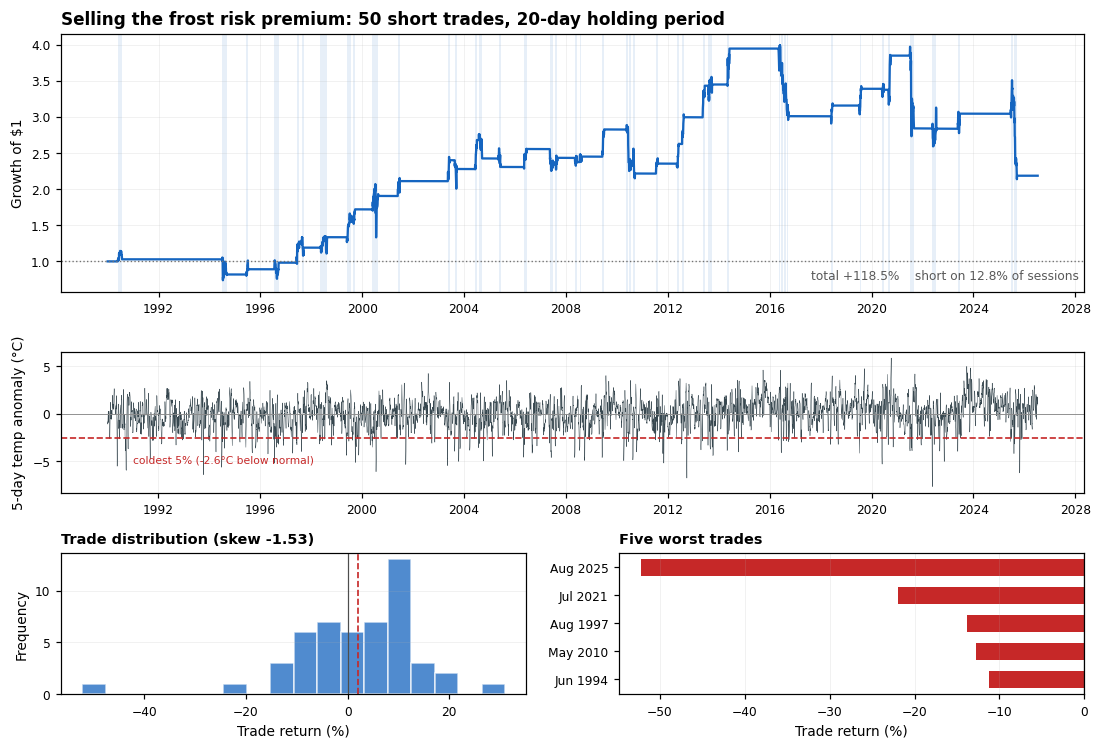

In [6]:
# ============================================================================
# EQUITY CURVE AND DIAGNOSTICS -- sell-the-frost-premium strategy


import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "pdf.fonttype": 42,          # embed TrueType so PDF text stays selectable
    "font.family": "DejaVu Sans",
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "figure.dpi": 110,
})


def summary_stats(pos, r, eq, tr):
    dd = (eq / eq.cummax() - 1).min()
    cagr = eq.iloc[-1] ** (TD / len(r)) - 1
    t = tr["ret"]
    return {
        "Total return":     f"{eq.iloc[-1] - 1:+.2%}",
        "CAGR":             f"{cagr:+.2%}",
        "Annualised vol":   f"{r.std() * np.sqrt(TD):.2%}",
        "Sharpe":           f"{r.mean() / r.std() * np.sqrt(TD):.3f}",
        "Sortino":          f"{r.mean() / r[r<0].std() * np.sqrt(TD):.3f}",
        "Max drawdown":     f"{dd:.2%}",
        "Calmar":           f"{cagr / abs(dd):.3f}",
        "Time in market":   f"{(pos != 0).mean():.2%}",
        "Trades":           f"{len(tr)}",
        "Hit rate":         f"{(t > 0).mean():.0%}",
        "Mean trade":       f"{t.mean():+.2%}",
        "Median trade":     f"{t.median():+.2%}",
        "Trade skewness":   f"{t.skew():.2f}",
        "t-statistic":      f"{t.mean()/(t.std()/np.sqrt(len(t))):.2f}",
    }

for k, v in summary_stats(pos, r, eq, tr).items():
    print(f"{k:<18}{v:>12}")

def plot_results(d, pos, eq, tr, save_as="frost_premium_equity.pdf"):
    fig = plt.figure(figsize=(12, 7.8))
    gs = fig.add_gridspec(3, 2, height_ratios=[2.1, 1.15, 1.15],
                          hspace=0.33, wspace=0.20)

    # ---- 1. equity curve, shaded where the strategy is short
    ax = fig.add_subplot(gs[0, :])
    ax.plot(d["date"], eq, color="#1565c0", lw=1.5, rasterized=True)
    ax.axhline(1.0, color="0.45", ls=":", lw=0.9)
    ax.fill_between(d["date"], 0, 1, where=(pos != 0), transform=ax.get_xaxis_transform(),
                    color="#1565c0", alpha=0.10, lw=0, rasterized=True)
    ax.set_ylabel("Growth of $1", fontsize=9)
    ax.grid(alpha=0.22); ax.tick_params(labelsize=8)
    ax.set_title(f"Selling the frost risk premium: {len(tr)} short trades, "
                 f"{HOLD}-day holding period",
                 fontsize=11, fontweight="bold", loc="left")
    ax.text(0.995, 0.05,
            f"total {eq.iloc[-1]-1:+.1%}    short on {(pos != 0).mean():.1%} of sessions",
            transform=ax.transAxes, ha="right", fontsize=8, color="0.35")
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # ---- 2. the signal: temperature anomaly against its 5th-percentile trigger
    ax2 = fig.add_subplot(gs[1, :])
    thr = d["anom5"].quantile(QUANTILE)
    ax2.plot(d["date"], d["anom5"], lw=0.3, color="#37474f", rasterized=True)
    ax2.axhline(thr, color="#c62828", ls="--", lw=1.1)
    ax2.axhline(0, color="0.55", lw=0.6)
    ax2.set_ylabel("5-day temp anomaly (\u00b0C)", fontsize=9)
    ax2.text(d["date"].iloc[250], thr - 2.6,
             f"coldest {QUANTILE:.0%} ({thr:.1f}\u00b0C below normal)",
             fontsize=7, color="#c62828")
    ax2.grid(alpha=0.22); ax2.tick_params(labelsize=8)
    ax2.xaxis.set_major_locator(mdates.YearLocator(4))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # ---- 3. distribution of trade returns: the insurance signature
    ax3 = fig.add_subplot(gs[2, 0])
    ax3.hist(tr["ret"] * 100, bins=18, color="#1565c0", alpha=0.75, edgecolor="white")
    ax3.axvline(0, color="0.3", lw=0.8)
    ax3.axvline(tr["ret"].mean() * 100, color="#c62828", ls="--", lw=1.1)
    ax3.set_xlabel("Trade return (%)", fontsize=9)
    ax3.set_ylabel("Frequency", fontsize=9)
    ax3.grid(alpha=0.22, axis="y"); ax3.tick_params(labelsize=8)
    ax3.set_title(f"Trade distribution (skew {tr['ret'].skew():.2f})",
                  fontsize=9.5, fontweight="bold", loc="left")

    # ---- 4. the five worst trades: where the insurance pays out
    ax4 = fig.add_subplot(gs[2, 1])
    worst = tr.nsmallest(5, "ret").iloc[::-1]
    ax4.barh(range(len(worst)), worst["ret"] * 100, color="#c62828", height=0.6)
    ax4.set_yticks(range(len(worst)))
    ax4.set_yticklabels([f"{t:%b %Y}" for t in worst["entry"]], fontsize=7.5)
    ax4.axvline(0, color="0.3", lw=0.8)
    ax4.set_xlabel("Trade return (%)", fontsize=9)
    ax4.grid(alpha=0.22, axis="x"); ax4.tick_params(labelsize=8)
    ax4.set_title("Five worst trades", fontsize=9.5, fontweight="bold", loc="left")

    fig.savefig(save_as, bbox_inches="tight", pad_inches=0.25, dpi=300)
    print(f"figure saved -> {save_as}")
    return fig


#  run it
d = add_anomaly(load())
pos, n = build_positions(d)
r, eq = backtest(d, pos)
tr = trade_log(d, pos)

print("\n=== SUMMARY ===")
for k, v in summary_stats(pos, r, eq, tr).items():
    print(f"{k:<18}{v:>12}")

fig = plot_results(d, pos, eq, tr)
plt.show()